In [76]:
import pandas as pd

# Charger les fichiers de données
file_path1 = "players_stats_by_season_full_details.xlsx"
file_path2 = "NBA_Anthropometric.csv"

df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2)

# Afficher les deux DataFrames
display(df1.head())
display(df2.head())

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,birth_date,height,height_cm,weight,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,"Mar 6, 1972",2025-01-07 00:00:00,216.0,325.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,"Jan 26, 1977",2025-06-06 00:00:00,198.0,220.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,"Jul 24, 1963",2025-09-06 00:00:00,206.0,265.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,"Jun 7, 1975",6-0,183.0,165.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,"Jul 23, 1968",2025-04-06 00:00:00,193.0,180.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics


,player_name,position,height,height_with_shoes,weight,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,Trey Alexander,SG,191.14,NaN,83.73,208.28,257.81,NaN,21.59,22.22,2023
1,Amari Bailey,SG,191.14,NaN,86.55,200.66,262.89,NaN,20.32,23.50,2023
2,Emoni Bates,SF,203.84,NaN,81.28,205.74,266.70,NaN,20.32,20.96,2023
3,Reece Beekman,PG,186.69,NaN,86.45,200.66,255.27,NaN,21.59,20.96,2023
4,Anthony Black,PG,197.48,NaN,95.25,201.93,260.35,NaN,20.96,24.13,2023


In [77]:
# Extraire les noms uniques de df2
noms_uniques_df2 = set(df2['player_name'].unique())

# Extraire les noms uniques de df1
noms_uniques_df1 = set(df1['Player'].unique())

# Trouver combien de noms uniques de df2 sont présents dans df1
noms_communs = noms_uniques_df2.intersection(noms_uniques_df1)
print(f"Nombre de noms uniques de df2 présents dans df1 : {len(noms_communs)}")

Nombre de noms uniques de df2 présents dans df1 : 947


In [78]:
# Filtrer df1 pour ne garder que les lignes dont le nom du joueur est dans noms_communs
df1_trie = df1[df1['Player'].isin(noms_communs)]
#display(df1_trie.head())
df1_trie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6269 entries, 42 to 53787
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   League       6269 non-null   object 
 1   Season       6269 non-null   object 
 2   Stage        6269 non-null   object 
 3   Player       6269 non-null   object 
 4   Team         6269 non-null   object 
 5   GP           6269 non-null   int64  
 6   MIN          6269 non-null   float64
 7   FGM          6269 non-null   int64  
 8   FGA          6269 non-null   int64  
 9   3PM          6269 non-null   int64  
 10  3PA          6269 non-null   int64  
 11  FTM          6269 non-null   int64  
 12  FTA          6269 non-null   int64  
 13  TOV          6269 non-null   int64  
 14  PF           6269 non-null   int64  
 15  ORB          6269 non-null   int64  
 16  DRB          6269 non-null   int64  
 17  REB          6269 non-null   int64  
 18  AST          6269 non-null   int64  
 19  STL      

In [79]:
#tri sur la ligue NBA
df1_trie_NBA = df1_trie[df1_trie['League'] == 'NBA']
#df1_trie_NBA.info()
#display(df1_trie_NBA.head())
#display(df1_trie_NBA.tail())

In [80]:
# Compter les joueurs uniques dans la ligue NBA après le tri
liste_trie_NBA_uniqueplayer = df1_trie_NBA['Player'].unique()
print(f"il y a {len(liste_trie_NBA_uniqueplayer)} joueurs uniques dans la ligue NBA après le tri.")

il y a 493 joueurs uniques dans la ligue NBA après le tri.


In [81]:
import unicodedata
#normalise les noms pour une meilleure correspondance
def normalize_name(s):
    if pd.isna(s):
        return s
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.replace('.', '').replace("'", '').replace('-', ' ')
    s = ' '.join(s.split())
    return s

# create normalized name columns
df1['player_norm'] = df1['Player'].apply(normalize_name)
df2['player_norm'] = df2['player_name'].apply(normalize_name)

# optional: reduce duplicates in df2 if there are multiple anthropometric rows per player
df2_unique = df2.drop_duplicates(subset=['player_norm']).copy()

# perform inner merge on normalized names (keeps only players present in both)
merged = pd.merge(df1, df2_unique, on='player_norm', how='inner', suffixes=('_stats','_anthro'))

# drop helper column if you don't want it
# merged = merged.drop(columns=['player_norm'])

# inspect results
print(f"Merged rows: {len(merged)}")
display(merged.head())

# save merged dataset
merged.to_csv('merged_players_stats_anthro.csv', index=False)

Merged rows: 6366


,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,position,height_anthro,height_with_shoes,weight_anthro,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,NBA,1999 - 2000,Regular_Season,Glen Rice,LAL,80,2530.0,421,980,84,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
1,NBA,1999 - 2000,Regular_Season,Jaren Jackson,SAS,81,1691.0,186,488,108,...,PF/C,207.64,211.46,107.05,226.70,279.40,7.20,25.40,25.40,2018
2,NBA,1999 - 2000,Playoffs,Glen Rice,LAL,23,766.0,93,228,28,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
3,Euroleague,2000 - 2001,International,Marko Jaric,BOL,22,631.3,79,180,17,...,SG/SF,199.39,NaN,95.25,205.74,264.16,NaN,NaN,NaN,2000
4,Euroleague,2000 - 2001,International,Igor Rakocevic,BUD,11,327.9,50,120,10,...,PG,189.23,NaN,83.46,196.22,254.00,NaN,NaN,NaN,2000


In [82]:
#cleaning data, on supprime les colonnes height_stats, birth_month birth_year and player_name

cols_to_drop = ['height_stats', 'birth_month', 'birth_year', 'player_name']

# drop from merged (safe: only drop columns that exist)
merged = merged.drop(columns=[c for c in cols_to_drop if c in merged.columns])

# save cleaned dataset
merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)


In [83]:
# convertire les dates de naissance en format datetime
# Convert birth_date like "Jan 26, 2002" -> "26.01.2002"
# Vérifie si la colonne 'birth_date' existe
if 'birth_date' in merged.columns:

    # 1️⃣ Parse les dates textuelles courantes
    # Exemple : "Jan 26, 2002"
    merged['birth_date_parsed'] = pd.to_datetime(
        merged['birth_date'], 
        errors='coerce', 
        infer_datetime_format=True
    )

    # 2️⃣ Fallback pour les suffixes anglais (1st, 2nd, 3rd, 4th, ...)
    mask = merged['birth_date_parsed'].isna() & merged['birth_date'].notna()
    if mask.any():
        tmp = (
            merged.loc[mask, 'birth_date']
            .astype(str)
            .str.lower()
            .str.replace(r'(\d)(st|nd|rd|th)', r'\1', regex=True)
        )
        merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
            tmp, 
            errors='coerce', 
            infer_datetime_format=True
        )

    # 3️⃣ Formater la colonne finale en "dd.mm.yyyy" (NaT → reste NaN)
    merged['birth_date'] = merged['birth_date_parsed'].dt.strftime('%d.%m.%Y')

    # 4️⃣ Supprimer la colonne temporaire
    merged = merged.drop(columns=['birth_date_parsed'])

    # 5️⃣ Sauvegarder le résultat
    merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)

else:
    print("Column 'birth_date' not found in merged.")

merged['birth_date'] = pd.to_datetime(merged['birth_date'], format='%d.%m.%Y', errors='coerce')

C:\Users\yochi\AppData\Local\Temp\ipykernel_18620\3631705391.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['birth_date_parsed'] = pd.to_datetime(
C:\Users\yochi\AppData\Local\Temp\ipykernel_18620\3631705391.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
C:\Users\yochi\AppData\Local\Temp\ipykernel_18620\3631705391.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please

In [84]:
# calcule de l'âge des joueurs
today = pd.Timestamp.today()
merged['age_actuel'] = (today - merged['birth_date']).dt.days // 365.25

# calcule de l'âge des joueurs au début de la saison


In [ ]:
#calcul de l'âge au début de la saison

def calcul_age_debut_saison(merged):
    """
    Calcule l'âge du joueur au début de la saison (1er octobre de l'année de début),
    en récupérant les 4 premiers chiffres de la colonne 'Season'.
    """
    # Extraire les 4 premiers caractères (année de début)
    merged['start_year'] = (
        merged['Season']
        .astype(str)
        .str[:4]
        .str.extract('(\d{4})')  # garde uniquement les chiffres
        .astype(float)
        .astype('Int64')
    )

    # Crée la date de début de saison (1er octobre de l’année de début)
    merged['season_start_date'] = pd.to_datetime(
        merged['start_year'].astype(str) + '-10-01',
        errors='coerce'
    )

    # Calcul de l'âge au début de la saison
    merged['age_debut_saison'] = ((merged['season_start_date'] - merged['birth_date']).dt.days / 365.25).round(1)

    return merged

# Application
merged = calcul_age_debut_saison(merged)

In [86]:
print(merged.columns)

Index(['League', 'Season', 'Stage', 'Player', 'Team', 'GP', 'MIN', 'FGM',
       'FGA', '3PM', '3PA', 'FTM', 'FTA', 'TOV', 'PF', 'ORB', 'DRB', 'REB',
       'AST', 'STL', 'BLK', 'PTS', 'birth_date', 'height_cm', 'weight_stats',
       'weight_kg', 'nationality', 'high_school', 'draft_round', 'draft_pick',
       'draft_team', 'player_norm', 'position', 'height_anthro',
       'height_with_shoes', 'weight_anthro', 'wingspan', 'standing_reach',
       'body_fat_percentage', 'hand_length', 'hand_width', 'draft_year',
       'age_actuel', 'start_year', 'season_start_date', 'age_debut_saison'],
      dtype='object')


In [87]:
nb_nan = merged['MIN'].isna().sum()
print("Nombre de NaN dans la colonne MIN :", nb_nan)

Nombre de NaN dans la colonne MIN : 0


In [88]:
print(merged['MIN'].dtype)

float64


In [89]:
print(merged['MIN'].isnull().sum())

0


In [90]:
# extraire minutes jouées
minutes = merged['MIN']
print('temps minimum joué par un joueur',minutes.min())
print('temps maximum joué par un joueur',minutes.max())

temps minimum joué par un joueur 0.8
temps maximum joué par un joueur 3388.0


In [91]:
# colonnes/statistiques à normaliser par minute
stats = ['FGM','FGA','3PM','3PA','FTM','FTA','TOV','PF','ORB','DRB','REB','AST','STL','BLK','PTS']

# créer colonnes per minute
created = []
for s in stats:
    if s in merged.columns:
        merged[f'{s}_per_min'] = merged[s].astype(float) / minutes
        merged[f'{s}_per_min'] = merged[f'{s}_per_min'].round(2)
        created.append(f'{s}_per_min')

# option: remplacer NaN par 0 si vous préférez
# merged[created] = merged[created].fillna(0)

print("Colonnes créées :", created)


Colonnes créées : ['FGM_per_min', 'FGA_per_min', '3PM_per_min', '3PA_per_min', 'FTM_per_min', 'FTA_per_min', 'TOV_per_min', 'PF_per_min', 'ORB_per_min', 'DRB_per_min', 'REB_per_min', 'AST_per_min', 'STL_per_min', 'BLK_per_min', 'PTS_per_min']


In [92]:
#créer une colonne EFF_per_min (mesure de l'efficacité d'un joueur par minute jouée)

merged['EFF_per_min'] = (
    (merged['PTS_per_min'] + merged['REB_per_min'] + merged['AST_per_min'] + merged['STL_per_min'] + merged['BLK_per_min'])
    - ((merged['FGA_per_min'] - merged['FGM_per_min']) + (merged['FTA_per_min'] - merged['FTM_per_min']) + merged['TOV_per_min'])
)


In [93]:
liste_teams = merged['Team'].unique()
len(liste_teams)

351

# Copier le DataFrame pour ne pas toucher à l'original
merged_dum = merged.copy()

team_col = 'Team'
drop_first = True
prefix = 'TEAM'

# Réduction si trop de modalités
n_unique = merged_dum[team_col].nunique(dropna=True)
col_to_encode = team_col
if n_unique > 50:
    top_teams = merged_dum[team_col].value_counts().nlargest(30).index
    col_to_encode = '_team_reduced'
    merged_dum[col_to_encode] = merged_dum[team_col].where(merged_dum[team_col].isin(top_teams), 'OTHER')

# Création des variables dummy
dummies = pd.get_dummies(
    merged_dum[col_to_encode],
    prefix=prefix,
    dummy_na=False,
    drop_first=drop_first if n_unique <= 50 else False,
    dtype=int
)
merged_dum = pd.concat([merged_dum, dummies], axis=1)

# Nettoyage si nécessaire
if col_to_encode == '_team_reduced':
    merged_dum.drop(columns=[col_to_encode], inplace=True)

print(f"Dummy variables créées depuis '{team_col}' — {dummies.shape[1]} colonnes (exemple: {dummies.columns[:5].tolist()})")

 # save result
merged_dum.to_csv('merged_dum.csv', index=False)

In [94]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   League               6366 non-null   object        
 1   Season               6366 non-null   object        
 2   Stage                6366 non-null   object        
 3   Player               6366 non-null   object        
 4   Team                 6366 non-null   object        
 5   GP                   6366 non-null   int64         
 6   MIN                  6366 non-null   float64       
 7   FGM                  6366 non-null   int64         
 8   FGA                  6366 non-null   int64         
 9   3PM                  6366 non-null   int64         
 10  3PA                  6366 non-null   int64         
 11  FTM                  6366 non-null   int64         
 12  FTA                  6366 non-null   int64         
 13  TOV                  6366 non-nul

In [95]:
# garder uniquement les lignes où la league est NBA
merged_NBA = merged[merged['League'] == 'NBA']

print(f"Lignes restantes après filtrage : {len(merged)}")

# sauvegarder le dataset filtré
merged_NBA.to_csv('merged_NBA.csv', index=False)


Lignes restantes après filtrage : 6366


In [96]:
display(merged_NBA[['height_cm', 'height_anthro']].head(10))
merged[['height_cm', 'height_anthro']].head(10)

,height_cm,height_anthro
0,203.0,194.31
1,193.0,207.64
2,203.0,194.31
7,203.0,194.31
8,203.0,201.30
9,206.0,203.20
10,203.0,194.31
11,185.0,182.24
18,198.0,194.94
19,203.0,203.84


,height_cm,height_anthro
0,203.0,194.31
1,193.0,207.64
2,203.0,194.31
3,201.0,199.39
4,191.0,189.23
5,218.0,215.26
6,193.0,189.23
7,203.0,194.31
8,203.0,201.30
9,206.0,203.20


In [97]:
print(merged.columns.tolist())

['League', 'Season', 'Stage', 'Player', 'Team', 'GP', 'MIN', 'FGM', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'TOV', 'PF', 'ORB', 'DRB', 'REB', 'AST', 'STL', 'BLK', 'PTS', 'birth_date', 'height_cm', 'weight_stats', 'weight_kg', 'nationality', 'high_school', 'draft_round', 'draft_pick', 'draft_team', 'player_norm', 'position', 'height_anthro', 'height_with_shoes', 'weight_anthro', 'wingspan', 'standing_reach', 'body_fat_percentage', 'hand_length', 'hand_width', 'draft_year', 'age_actuel', 'start_year', 'season_start_date', 'age_debut_saison', 'FGM_per_min', 'FGA_per_min', '3PM_per_min', '3PA_per_min', 'FTM_per_min', 'FTA_per_min', 'TOV_per_min', 'PF_per_min', 'ORB_per_min', 'DRB_per_min', 'REB_per_min', 'AST_per_min', 'STL_per_min', 'BLK_per_min', 'PTS_per_min', 'EFF_per_min']


In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# création d'une fonction pour tracer la distribution des joueurs

def plot_player_distribution(df, player_col, value_col, unit=None):
    """
    Trace un histogramme + boxplot pour une colonne numérique (ex: height, age, weight)
    en ne comptant chaque joueur qu'une seule fois.
    
    Arguments :
    - df : DataFrame
    - player_col : str, nom de la colonne joueur
    - value_col : str, nom de la colonne numérique à tracer
    - unit : str, unité à afficher (ex: 'cm', 'kg', 'years')
    """

    # Supprimer les doublons
    merged_unique = merged.drop_duplicates(subset=[player_col])
    values = merged_unique[value_col].dropna()

    # Calculs descriptifs
    count = values.notna().sum()
    mean = values.mean()
    median = values.median()
    std = values.std()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    # Graphiques
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[3, 1]})

    # Histogramme + KDE
    sns.histplot(values, kde=True, bins=30, color='steelblue', ax=axes[0])
    axes[0].axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.1f} {unit or ''}")
    axes[0].axvline(median, color='green', linestyle='-.', label=f"Median: {median:.1f} {unit or ''}")
    axes[0].set_title(f"Distribution of player {value_col} ({count} unique players)")
    axes[0].set_xlabel(f"{value_col} ({unit or ''})")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=values, color='lightgray', ax=axes[1])
    axes[1].axvline(mean, color='red', linestyle='--')
    axes[1].set_xlabel(f"{value_col} ({unit or ''})")
    axes[1].set_title(f"Boxplot — mean: {mean:.1f} {unit or ''}, std: {std:.1f}, IQR: {iqr:.1f}")

    plt.tight_layout()
    plt.show()

    # Résumé numérique
    print(f"{value_col.upper()} — Count: {count}, Mean: {mean:.1f} {unit or ''}, Median: {median:.1f} {unit or ''}, Std: {std:.1f}, IQR: {iqr:.1f}")


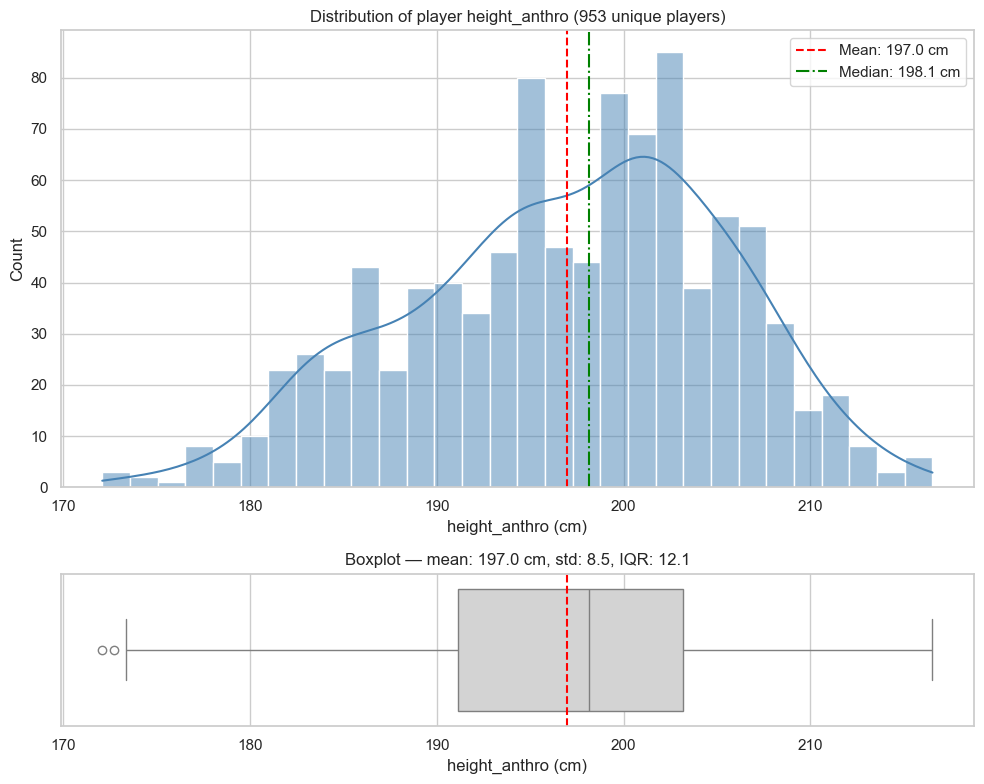

HEIGHT_ANTHRO — Count: 953, Mean: 197.0 cm, Median: 198.1 cm, Std: 8.5, IQR: 12.1


In [99]:
# appel de la fonction pour la taille des joueurs
plot_player_distribution(merged, player_col='Player', value_col='height_anthro', unit='cm')

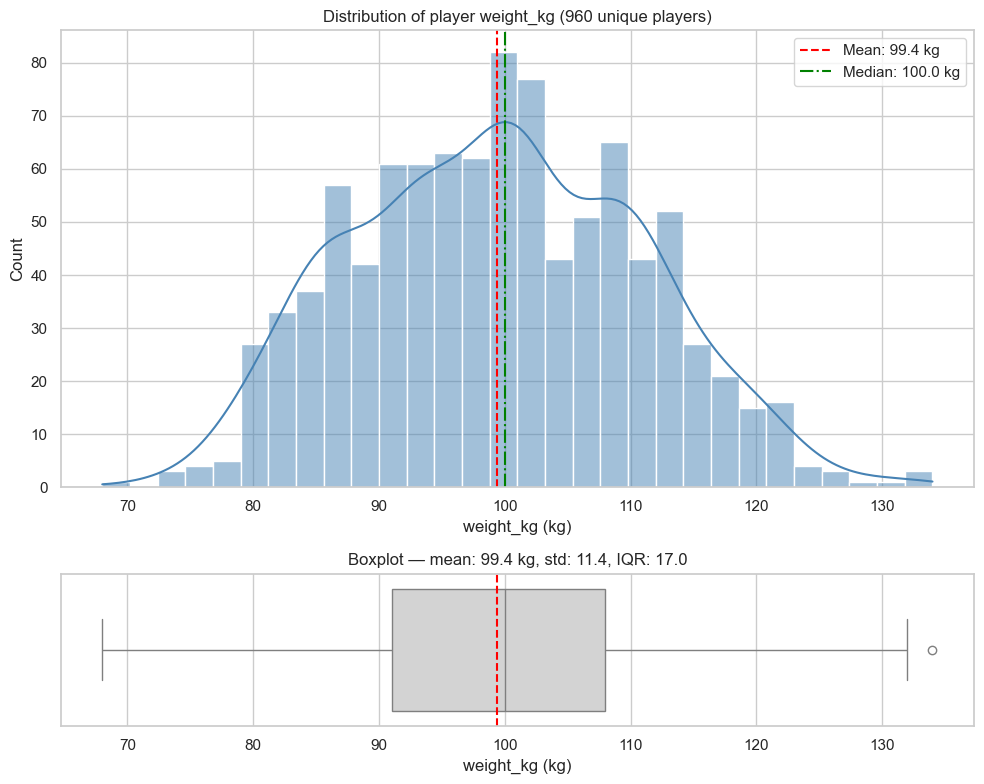

WEIGHT_KG — Count: 960, Mean: 99.4 kg, Median: 100.0 kg, Std: 11.4, IQR: 17.0


In [100]:
# appel de la fonction pour le poids des joueurs
plot_player_distribution(merged, player_col='Player', value_col='weight_kg', unit='kg')

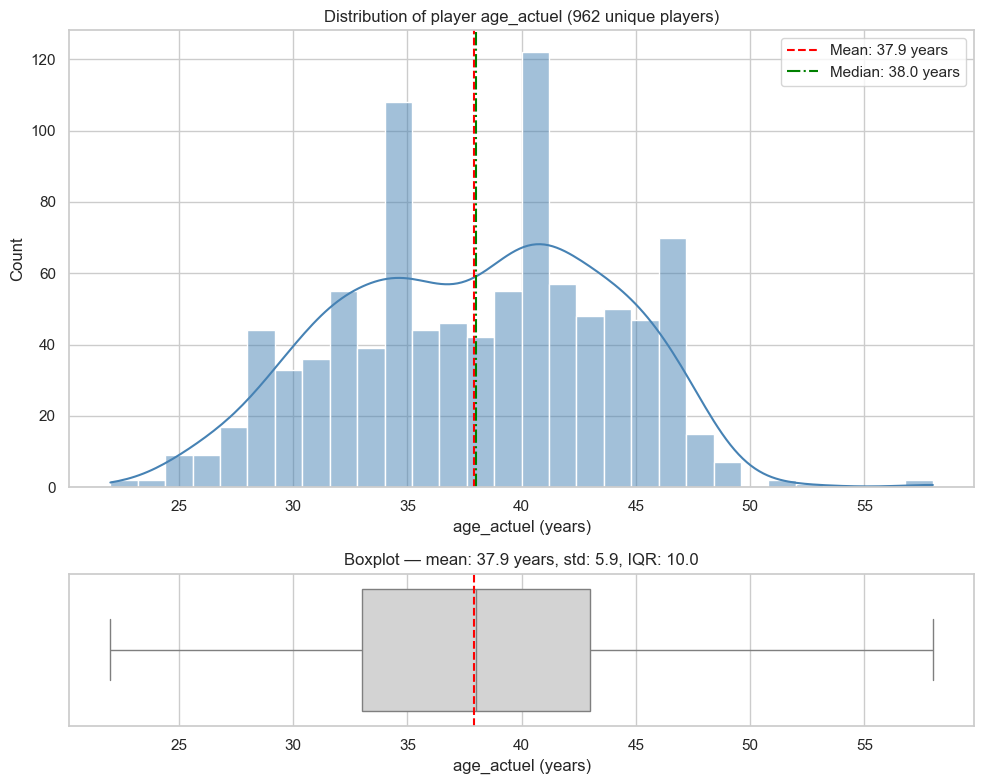

AGE_ACTUEL — Count: 962, Mean: 37.9 years, Median: 38.0 years, Std: 5.9, IQR: 10.0


In [102]:
# appel de la fonction pour l'âge des joueurs
plot_player_distribution(merged, player_col='Player', value_col='age_actuel', unit='years')

1.09
0.0
0.4758718190386429


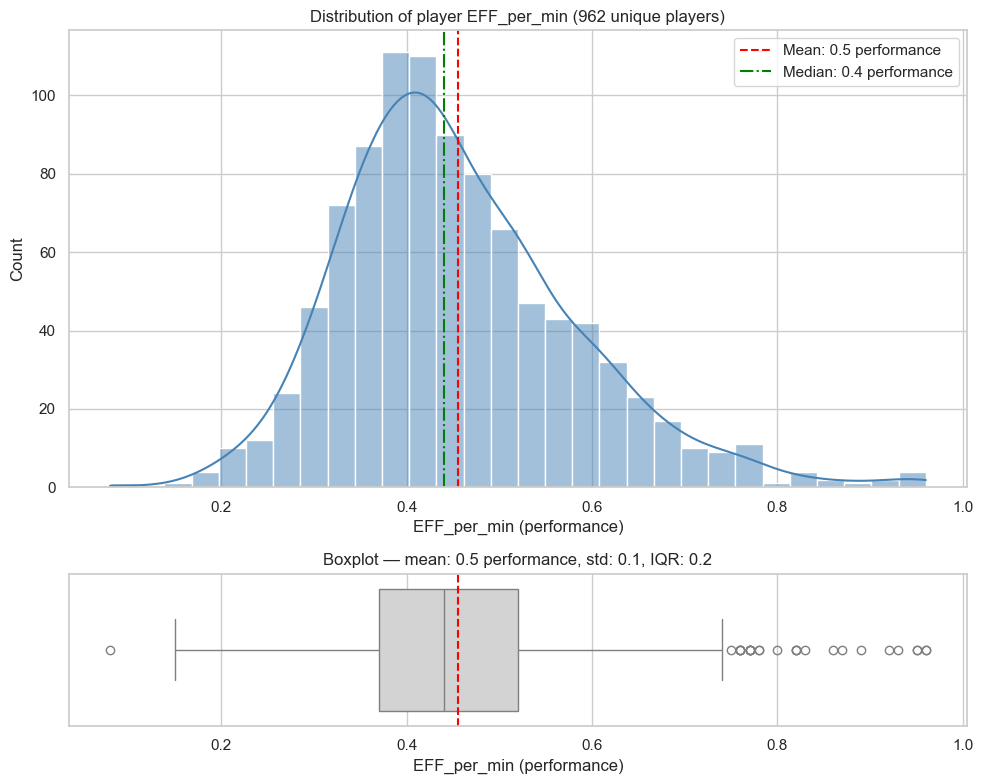

EFF_PER_MIN — Count: 962, Mean: 0.5 performance, Median: 0.4 performance, Std: 0.1, IQR: 0.2


In [ ]:
print(merged['EFF_per_min'].max())
print(merged['EFF_per_min'].min())
print(merged['EFF_per_min'].mean())
plot_player_distribution(merged, player_col='Player', value_col='EFF_per_min', unit='performance')

In [ ]:
import statsmodels.api as sm
import pandas as pd

def regression_lineaire(df, cible, variables):
    """
    Effectue une régression linéaire avec statsmodels.

    Paramètres
    ----------
    df : pd.DataFrame
        Ton DataFrame complet.
    cible : str
        Nom de la variable dépendante (y).
    variables : list
        Liste des variables explicatives (X).
    
    Retour
    ------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Le modèle ajusté.
    """
    # Vérifie la présence des colonnes
    colonnes = [cible] + variables
    data = df[colonnes].dropna()
    
    # Définition des variables
    X = data[variables]
    y = data[cible]
    
    # Ajout de la constante
    X = sm.add_constant(X)
    
    # Modèle
    model = sm.OLS(y, X).fit()
    
    # Affichage synthétique
    print("📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR")
    print(f"Variable dépendante : {cible}")
    print(f"Variables explicatives : {', '.join(variables)}\n")
    print(model.summary())
    
    return model


In [ ]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['height_anthro'])

📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : height_anthro

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     211.0
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.70e-46
Time:                        14:31:58   Log-Likelihood:                 2132.4
No. Observations:                3588   AIC:                            -4261.
Df Residuals:                    3586   BIC:                            -4248.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------

In [ ]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['wingspan'])

📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : wingspan

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     353.2
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           3.07e-75
Time:                        14:33:12   Log-Likelihood:                 2200.5
No. Observations:                3593   AIC:                            -4397.
Df Residuals:                    3591   BIC:                            -4385.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------

In [ ]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['weight_kg'])


📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : weight_kg

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     384.6
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.88e-81
Time:                        14:35:42   Log-Likelihood:                 2221.0
No. Observations:                3603   AIC:                            -4438.
Df Residuals:                    3601   BIC:                            -4426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [106]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['age_debut_saison'])


📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : age_debut_saison

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.03160
Date:                Mon, 10 Nov 2025   Prob (F-statistic):              0.859
Time:                        14:59:00   Log-Likelihood:                 2038.2
No. Observations:                3603   AIC:                            -4072.
Df Residuals:                    3601   BIC:                            -4060.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---